In [2]:
import pandas as pd
import numpy as np
!pip install pyodbc
import pyodbc
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (12,6)
sns.set_style('whitegrid')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 340.3/340.3 kB 6.6 MB/s eta 0:00:00


In [3]:
import pyodbc
import matplotlib.pyplot as plt

In [4]:
df = pd.read_csv("/content/AdventureWorks_Analysis 12.csv")
df.head()

,SalesOrderID,OrderDate,CustomerID,Territory,ProductName,Category,OrderQty,UnitPrice,LineTotal,TotalDue
0,43666,00:00.0,30052,Southwest,"Road-650 Red, 52",Bikes,1,419.4589,419.4589,5694.8564
1,43666,00:00.0,30052,Southwest,"Road-150 Red, 56",Bikes,1,2146.9620,2146.9620,5694.8564
2,43666,00:00.0,30052,Southwest,"ML Road Frame - Red, 48",Components,1,356.8980,356.8980,5694.8564
3,43666,00:00.0,30052,Southwest,"Road-450 Red, 44",Bikes,1,874.7940,874.7940,5694.8564
4,43666,00:00.0,30052,Southwest,"Road-650 Black, 44",Bikes,2,419.4589,838.9178,5694.8564


In [5]:
df.head()

,SalesOrderID,OrderDate,CustomerID,Territory,ProductName,Category,OrderQty,UnitPrice,LineTotal,TotalDue
0,43666,00:00.0,30052,Southwest,"Road-650 Red, 52",Bikes,1,419.4589,419.4589,5694.8564
1,43666,00:00.0,30052,Southwest,"Road-150 Red, 56",Bikes,1,2146.9620,2146.9620,5694.8564
2,43666,00:00.0,30052,Southwest,"ML Road Frame - Red, 48",Components,1,356.8980,356.8980,5694.8564
3,43666,00:00.0,30052,Southwest,"Road-450 Red, 44",Bikes,1,874.7940,874.7940,5694.8564
4,43666,00:00.0,30052,Southwest,"Road-650 Black, 44",Bikes,2,419.4589,838.9178,5694.8564


In [6]:
df.tail(5)

,SalesOrderID,OrderDate,CustomerID,Territory,ProductName,Category,OrderQty,UnitPrice,LineTotal,TotalDue
121312,72905,00:00.0,18832,Southwest,Mountain Tire Tube,Accessories,1,4.99,4.99,2580.1529
121313,72905,00:00.0,18832,Southwest,HL Mountain Tire,Accessories,1,35.00,35.00,2580.1529
121314,72925,00:00.0,26646,Southwest,"Touring-3000 Blue, 62",Bikes,1,742.35,742.35,995.9918
121315,72925,00:00.0,26646,Southwest,All-Purpose Bike Stand,Accessories,1,159.00,159.00,995.9918
121316,72928,00:00.0,24334,Southwest,"Road-750 Black, 44",Bikes,1,539.99,539.99,635.3529


In [7]:
df.shape

(121317, 10)

Observation :
The dataset contained over 120,000 sales transaction record

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 121317 entries, 0 to 121316
Data columns (total 10 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   SalesOrderID  121317 non-null  int64  
 1   OrderDate     121317 non-null  object 
 2   CustomerID    121317 non-null  int64  
 3   Territory     121317 non-null  object 
 4   ProductName   121317 non-null  object 
 5   Category      121317 non-null  object 
 6   OrderQty      121317 non-null  int64  
 7   UnitPrice     121317 non-null  float64
 8   LineTotal     121317 non-null  float64
 9   TotalDue      121317 non-null  float64
dtypes: float64(3), int64(3), object(4)
memory usage: 9.3+ MB


Observation : Most columns were fine but I converted the date columns into date format so I could analyze sales over time

In [9]:
df.describe()

,SalesOrderID,CustomerID,OrderQty,UnitPrice,LineTotal,TotalDue
count,121317.000000,121317.000000,121317.000000,121317.000000,121317.000000,121317.000000
mean,57827.363782,24345.630505,2.266080,465.093496,905.449207,24126.627959
std,9009.147902,6689.110387,2.491323,751.885081,1693.417389,32173.502712
min,43659.000000,11000.000000,1.000000,1.328200,1.374000,1.518300
25%,49884.000000,18177.000000,1.000000,21.490000,24.990000,623.750400
50%,57029.000000,29485.000000,1.000000,49.990000,134.982000,2785.517200
75%,65490.000000,29795.000000,3.000000,602.346000,1120.490000,41890.970300
max,75123.000000,30118.000000,44.000000,3578.270000,27893.619000,187487.825000


In [10]:
# categorialcal
df.describe(include='object')

,OrderDate,Territory,ProductName,Category
count,121317,121317,121317,121317
unique,1,10,266,4
top,00:00.0,Southwest,Water Bottle - 30 oz.,Accessories
freq,121317,25644,4688,41194


In [11]:
cat_col = df.select_dtypes(include='object')
cat_col.head()

,OrderDate,Territory,ProductName,Category
0,00:00.0,Southwest,"Road-650 Red, 52",Bikes
1,00:00.0,Southwest,"Road-150 Red, 56",Bikes
2,00:00.0,Southwest,"ML Road Frame - Red, 48",Components
3,00:00.0,Southwest,"Road-450 Red, 44",Bikes
4,00:00.0,Southwest,"Road-650 Black, 44",Bikes


In [12]:
num_col = df.select_dtypes(exclude='object')
num_col.head()

,SalesOrderID,CustomerID,OrderQty,UnitPrice,LineTotal,TotalDue
0,43666,30052,1,419.4589,419.4589,5694.8564
1,43666,30052,1,2146.9620,2146.9620,5694.8564
2,43666,30052,1,356.8980,356.8980,5694.8564
3,43666,30052,1,874.7940,874.7940,5694.8564
4,43666,30052,2,419.4589,838.9178,5694.8564


In [13]:
df.isnull().sum()

,0
SalesOrderID,0
OrderDate,0
CustomerID,0
Territory,0
ProductName,0
Category,0
OrderQty,0
UnitPrice,0
LineTotal,0
TotalDue,0


In [14]:
df.duplicated().sum()

np.int64(0)

In [15]:
df.drop_duplicates(inplace=True)

In [16]:
df['OrderDate'] = pd.to_datetime(df['OrderDate'])

In [17]:
df[['OrderQty','UnitPrice','LineTotal','TotalDue']].min()

,0
OrderQty,1.0000
UnitPrice,1.3282
LineTotal,1.3740
TotalDue,1.5183


In [18]:
# check unique vlaue in categorical coloumns
for col in cat_col.columns:
  print(f"\n{col}")
  print(df[col].nunique)


OrderDate
<bound method IndexOpsMixin.nunique of 0        2026-06-08
1        2026-06-08
2        2026-06-08
3        2026-06-08
4        2026-06-08
            ...    
121312   2026-06-08
121313   2026-06-08
121314   2026-06-08
121315   2026-06-08
121316   2026-06-08
Name: OrderDate, Length: 121317, dtype: datetime64[ns]>

Territory
<bound method IndexOpsMixin.nunique of 0         Southwest
1         Southwest
2         Southwest
3         Southwest
4         Southwest
            ...    
121312    Southwest
121313    Southwest
121314    Southwest
121315    Southwest
121316    Southwest
Name: Territory, Length: 121317, dtype: object>

ProductName
<bound method IndexOpsMixin.nunique of 0                Road-650 Red, 52
1                Road-150 Red, 56
2         ML Road Frame - Red, 48
3                Road-450 Red, 44
4              Road-650 Black, 44
                   ...           
121312         Mountain Tire Tube
121313           HL Mountain Tire
121314      Touring-3000 Blue, 6

In [19]:
# check category value
for col in ['Territory','Category']:
  print(f"\n{col}")
  print(df[col].unique())


Territory
['Southwest' 'Northwest' 'Canada' 'Central' 'Southeast' 'France'
 'Australia' 'Germany' 'United Kingdom' 'Northeast']

Category
['Bikes' 'Components' 'Clothing' 'Accessories']


In [20]:
# clean text columns
df['Territory'] = df['Territory'].str.strip()
df['Category'] = df['Category'].str.strip()
df['ProductName'] = df['ProductName'].str.strip()

In [21]:
num_cols = ['OrderQty','UnitPrice','LineTotal','TotalDue']
df[num_cols].skew

<bound method DataFrame.skew of         OrderQty  UnitPrice  LineTotal   TotalDue
0              1   419.4589   419.4589  5694.8564
1              1  2146.9620  2146.9620  5694.8564
2              1   356.8980   356.8980  5694.8564
3              1   874.7940   874.7940  5694.8564
4              2   419.4589   838.9178  5694.8564
...          ...        ...        ...        ...
121312         1     4.9900     4.9900  2580.1529
121313         1    35.0000    35.0000  2580.1529
121314         1   742.3500   742.3500   995.9918
121315         1   159.0000   159.0000   995.9918
121316         1   539.9900   539.9900   635.3529

[121317 rows x 4 columns]>

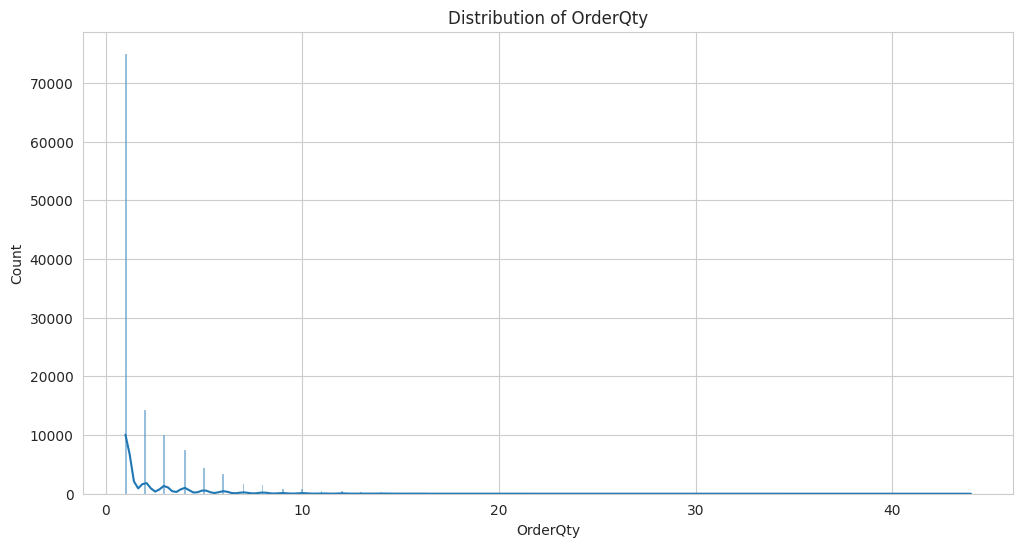

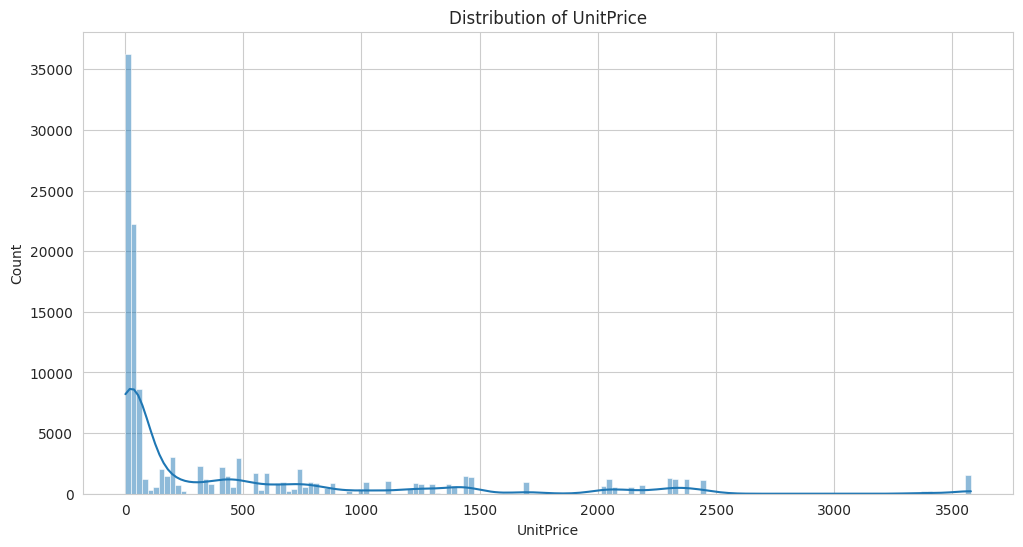

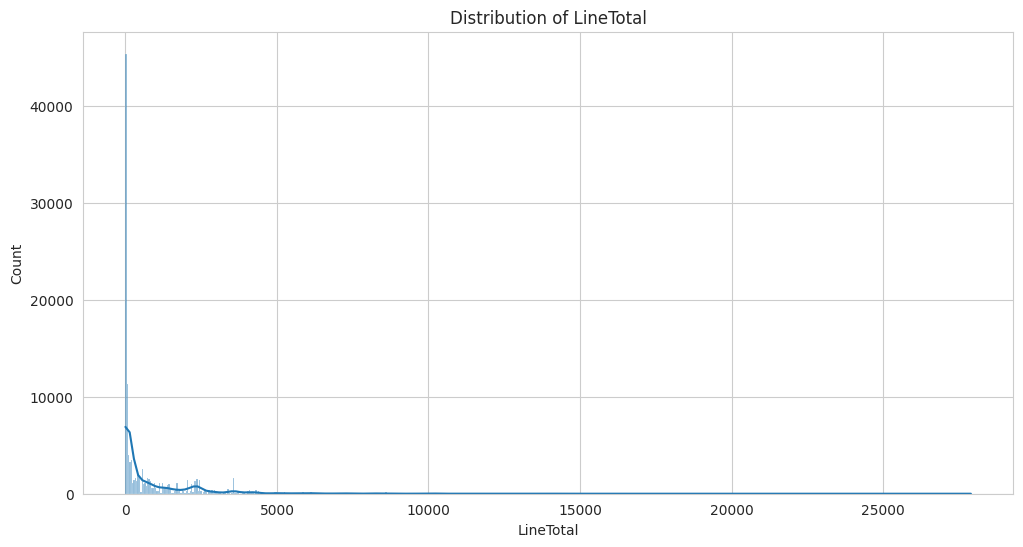

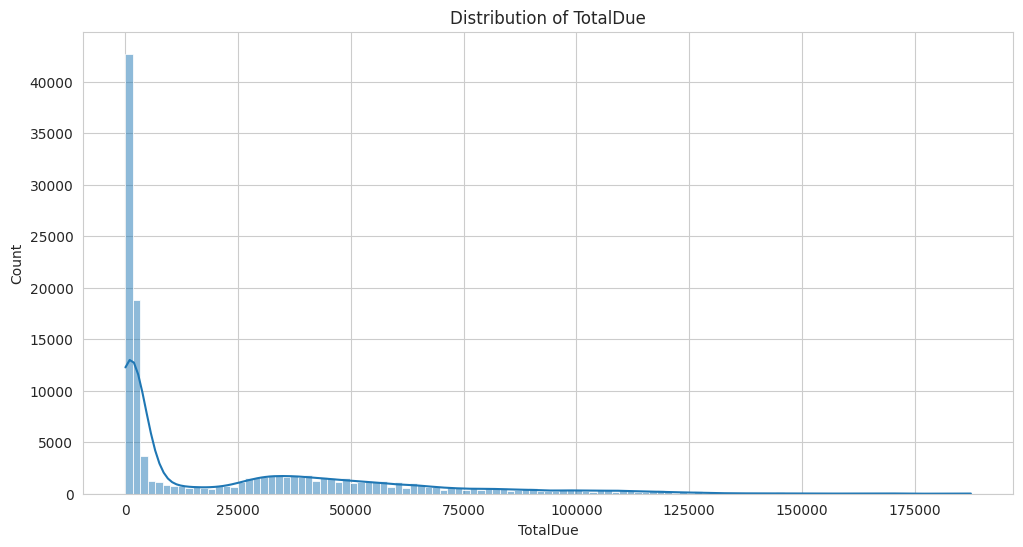

In [22]:
# Distribution of numeric features
for col in num_cols:
  sns.histplot(df[col],kde=True)
  plt.title(f'Distribution of {col}')
  plt.show()


Observation : Most features showed a right-skewed pattern, where the majority of records had smaller values and only a few had very large values. This is common in sales datasets because a small number of large transactions usually contribute a significant portion of the revenue

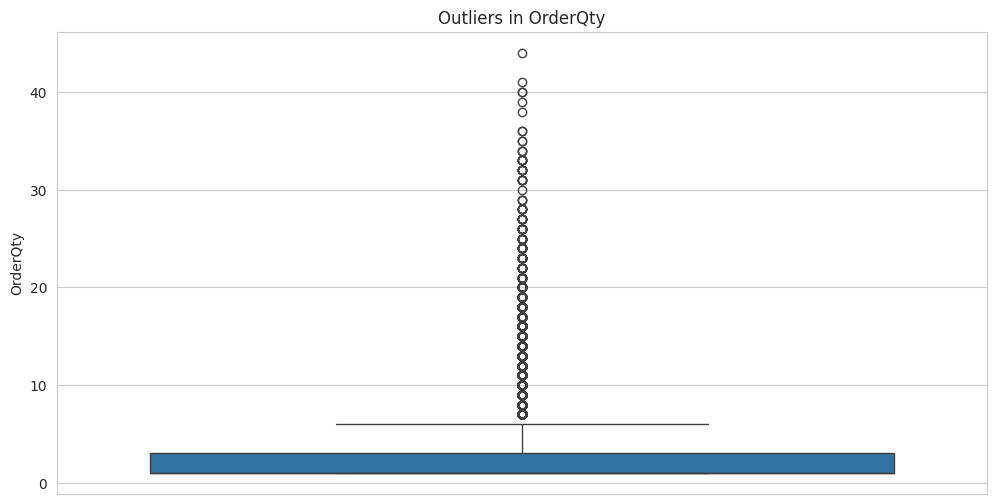

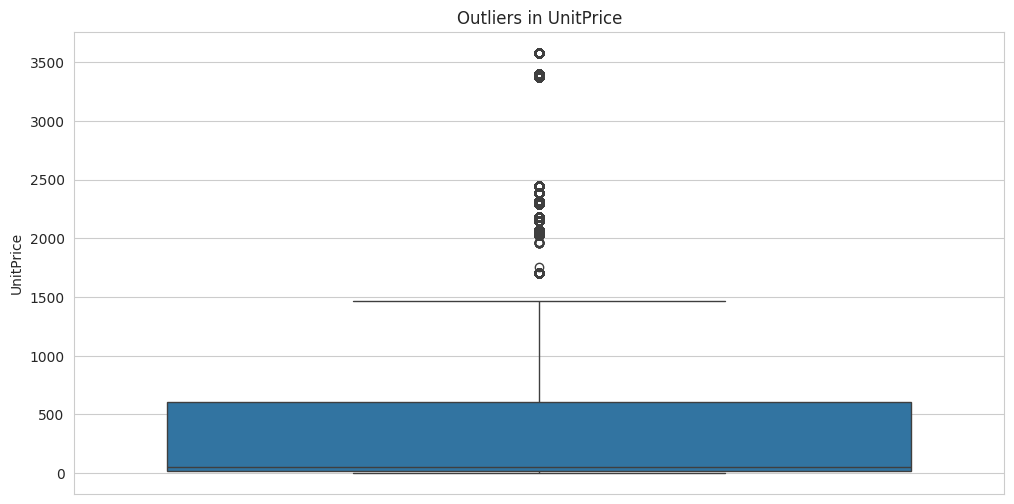

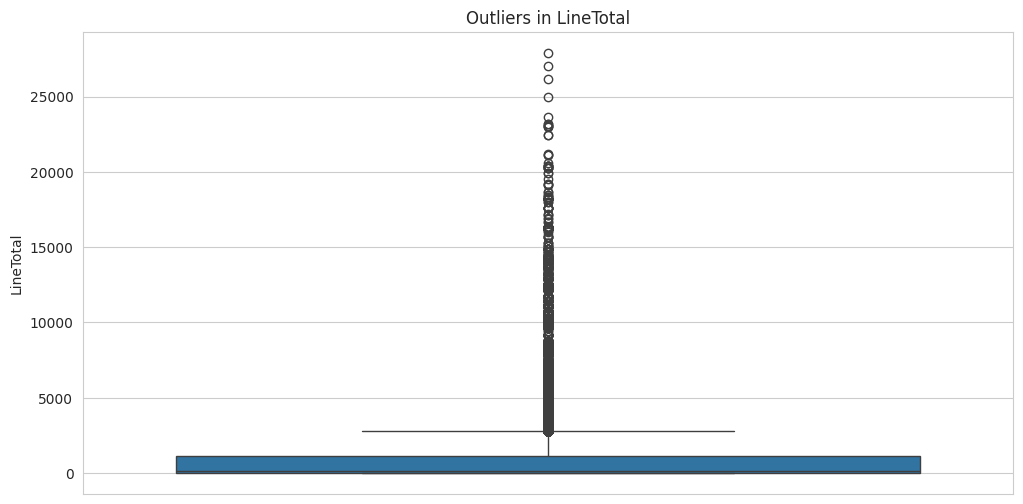

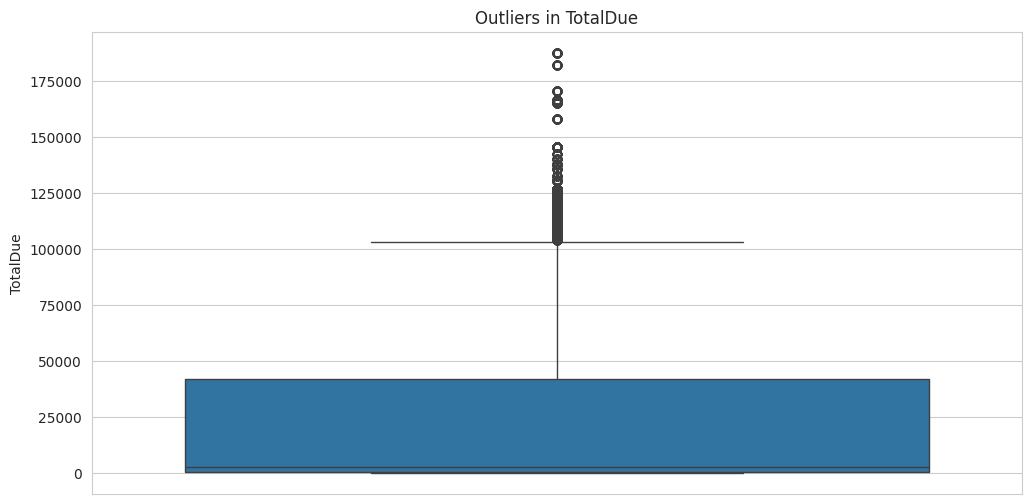

In [23]:
# Box plot for outliers
for col in num_cols:
  sns.boxplot(df[col])
  plt.title(f'Outliers in {col}')
  plt.show()

Observation :
The box plots indicated that columns such as TotalDue, LineTotal, and UnitPrice contained several outliers. This suggests that while most orders were of moderate value, a small number of orders had exceptionally high amounts, which contributed significantly to overall revenue.

In [24]:
# IQR outlier function
def remove_outlier_iqr(data,column):
  Q1 = data[column].quantile(0.25)
  Q3 = data[column].quantile(0.75)
  IQR = Q3 - Q1
  lower_bound = Q1 - 1.5 * IQR
  upper_bound = Q3 + 1.5 * IQR

  return data[(data[column] >= lower_bound) & (data[column] <= upper_bound)]


In [25]:
# remove duplicate
print("Before:",df.shape)
df_clean = remove_outlier_iqr(df, 'OrderQty')
print("After:",df_clean.shape)


Before: (121317, 10)
After: (114390, 10)


Observation :
After applying the IQR method, some extreme values were removed from the dataset. The number of records reduced from 121,317 to 114,390, showing that outliers were successfully identified and removed. This made the data more balanced for analysis

In [26]:
print("Before:",df.shape)
df_clean = remove_outlier_iqr(df, 'UnitPrice')
print("After:",df_clean.shape)

Before: (121317, 10)
After: (109878, 10)


Observation :
Unit prices showed limited extreme values. Most products fall within a consistent pricing rang

In [27]:
print("Before:",df.shape)
df_clean = remove_outlier_iqr(df, 'LineTotal')
df_clean = remove_outlier_iqr(df, 'TotalDue')
print("After:",df_clean.shape)


Before: (121317, 10)
After: (117234, 10)


Observation :
A few customers made very large purchases. Although these values appear as outliers, they may represent important customers and contribute significantly to revenue. Removing them might result in losing useful business insights





In [28]:
df_clean = remove_outlier_iqr(df, 'UnitPrice')
df_clean.head()

,SalesOrderID,OrderDate,CustomerID,Territory,ProductName,Category,OrderQty,UnitPrice,LineTotal,TotalDue
0,43666,2026-06-08,30052,Southwest,"Road-650 Red, 52",Bikes,1,419.4589,419.4589,5694.8564
2,43666,2026-06-08,30052,Southwest,"ML Road Frame - Red, 48",Components,1,356.8980,356.8980,5694.8564
3,43666,2026-06-08,30052,Southwest,"Road-450 Red, 44",Bikes,1,874.7940,874.7940,5694.8564
4,43666,2026-06-08,30052,Southwest,"Road-650 Black, 44",Bikes,2,419.4589,838.9178,5694.8564
5,43666,2026-06-08,30052,Southwest,"Road-650 Black, 60",Bikes,1,419.4589,419.4589,5694.8564


In [29]:
df_clean = remove_outlier_iqr(df_clean, 'OrderQty')
df_clean.head()

,SalesOrderID,OrderDate,CustomerID,Territory,ProductName,Category,OrderQty,UnitPrice,LineTotal,TotalDue
0,43666,2026-06-08,30052,Southwest,"Road-650 Red, 52",Bikes,1,419.4589,419.4589,5694.8564
2,43666,2026-06-08,30052,Southwest,"ML Road Frame - Red, 48",Components,1,356.8980,356.8980,5694.8564
3,43666,2026-06-08,30052,Southwest,"Road-450 Red, 44",Bikes,1,874.7940,874.7940,5694.8564
4,43666,2026-06-08,30052,Southwest,"Road-650 Black, 44",Bikes,2,419.4589,838.9178,5694.8564
5,43666,2026-06-08,30052,Southwest,"Road-650 Black, 60",Bikes,1,419.4589,419.4589,5694.8564


In [30]:
print("Original:", df.shape)
print("Cleaned :", df_clean.shape)

Original: (121317, 10)
Cleaned : (103040, 10)


In [31]:
# year column
df['Year'] = df['OrderDate'].dt.year
df['Year']

,Year
0,2026
1,2026
2,2026
3,2026
4,2026
...,...
121312,2026
121313,2026
121314,2026
121315,2026


Observation :    
The year was extracted from the order date so that yearly sales and order trends could be analyzed easily

In [32]:
# Month
df['month'] = df['OrderDate'].dt.month
df['month']

,month
0,6
1,6
2,6
3,6
4,6
...,...
121312,6
121313,6
121314,6
121315,6


Observation :    
The month was extracted from the order date to understand how sales changed from month to month

In [33]:
# order size
df['order_size'] = np.where(df['OrderQty'] > 100, 'large', 'small')
df['order_size'].tail()


,order_size
121312,small
121313,small
121314,small
121315,small
121316,small


Observation :    
Orders with quantities above 100 were marked as large orders, while the rest were marked as small orders

In [34]:
df['OrderSize'] = pd.cut(
    df['OrderQty'],
    bins=[0, 100, 500, np.inf],
    labels=['small', 'medium', 'large']
)
df['OrderSize']

,OrderSize
0,small
1,small
2,small
3,small
4,small
...,...
121312,small
121313,small
121314,small
121315,small


Observation :    
Orders were divided into three groups: small, medium, and large, based on the number of items purchased

In [35]:
#which type of order is most common
df['OrderSize'].value_counts()

,count
OrderSize,
small,121317
medium,0
large,0


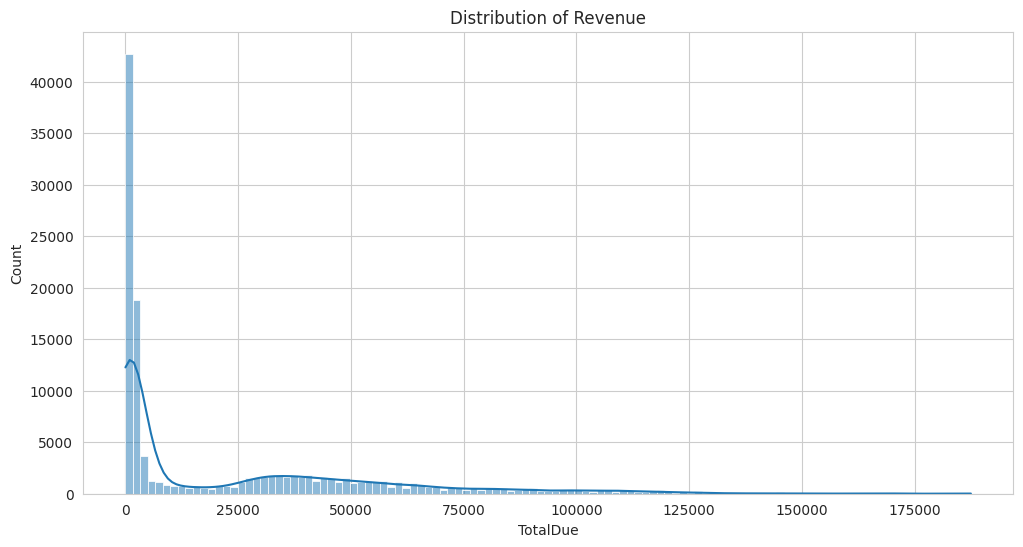

In [36]:
# Revenue distribution
sns.histplot(df['TotalDue'],kde=True)
plt.title('Distribution of Revenue')
plt.show()

Observation :    
Most orders generated a normal amount of revenue while only a few orders generated very high revenue. This shows that a small number of large orders contributed a significant portion of the total sales

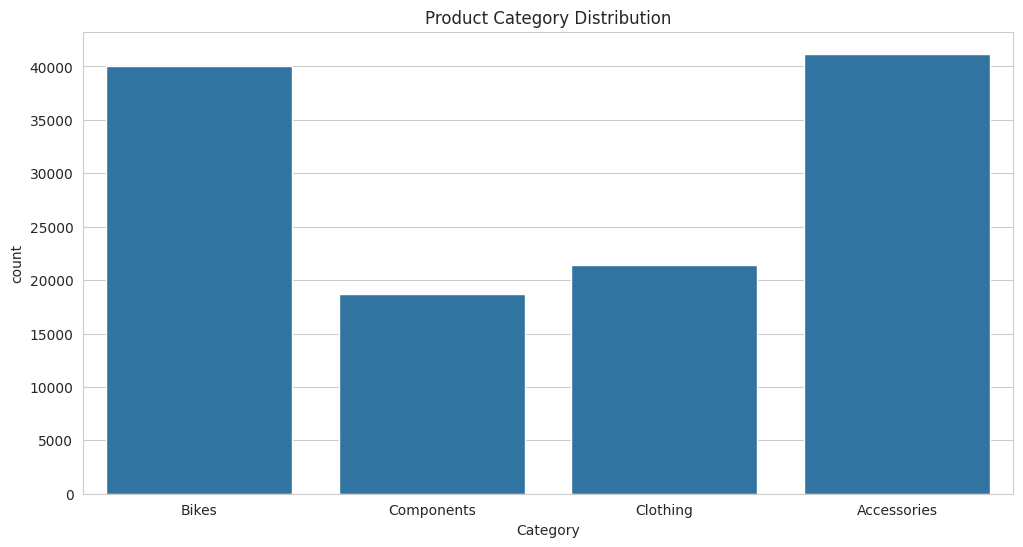

In [37]:
# Product Category Distribution
sns.countplot(x='Category',data=df)
plt.title('Product Category Distribution')
plt.show()

Observation :     
Some product categories received significantly more orders than others showing that customer demand is not evenly distributed across categories

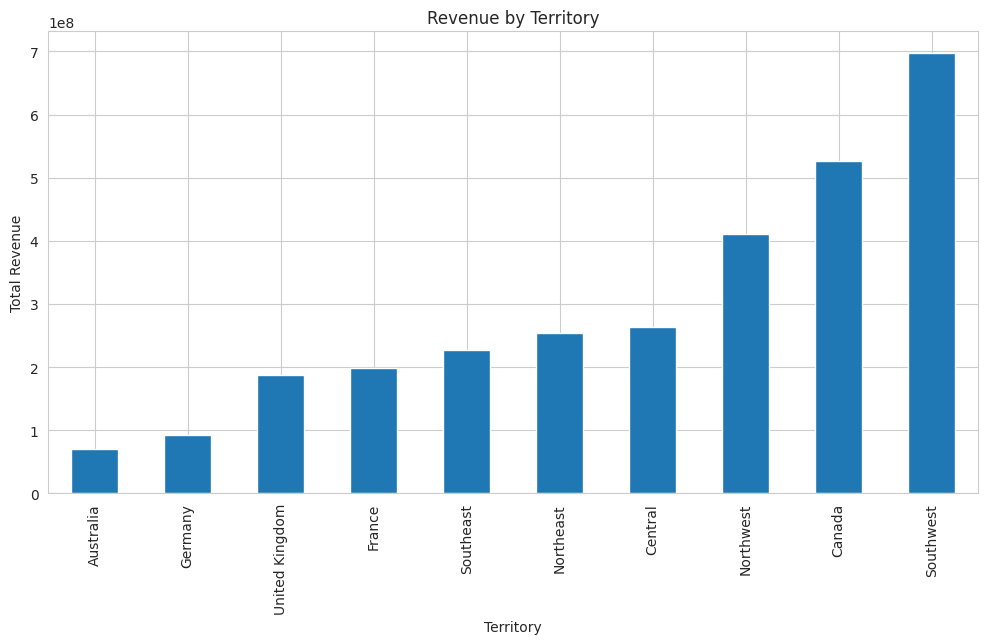

In [38]:
# Revenue by territory
territory_revenue = df.groupby('Territory')['TotalDue'].sum().sort_values()
territory_revenue.plot(kind='bar')
plt.title('Revenue by Territory')
plt.ylabel('Total Revenue')
plt.show()

Observation :     
Certain territories generated much higher revenue than others indicating stronger sales performance in specific regions

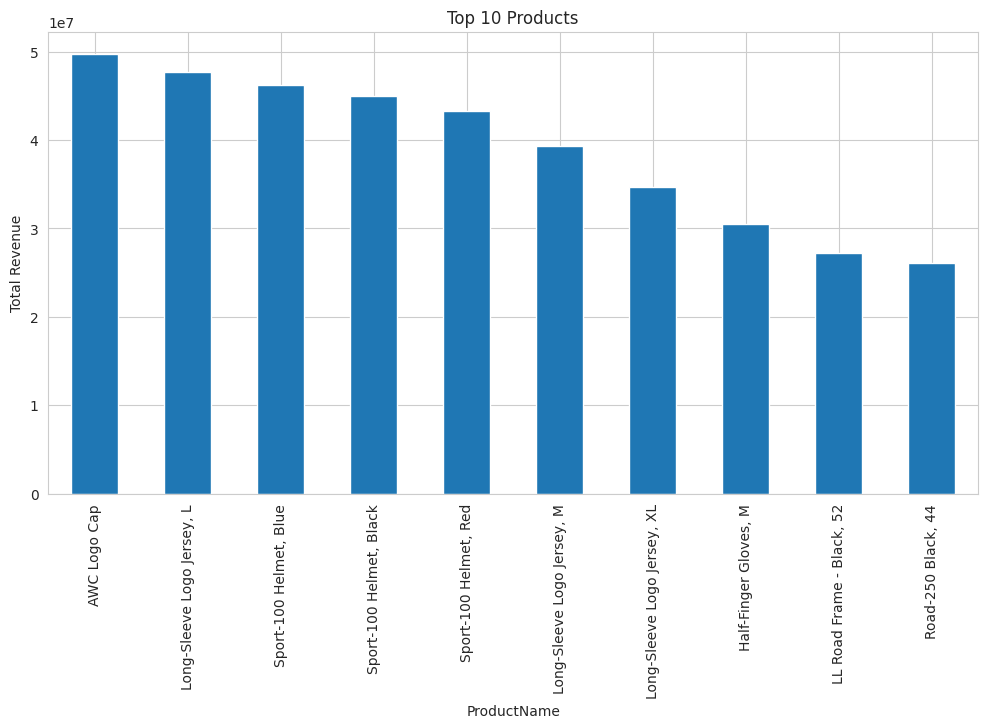

In [39]:
#Top 10 Products
top_products = df.groupby('ProductName')['TotalDue'].sum().nlargest(10)
top_products.plot(kind='bar')
plt.title('Top 10 Products')
plt.ylabel('Total Revenue')
plt.show()

Observation :    
A few products generated most of the sales while the remaining products contributed less. This shows that some products are much more popular and play a major role in driving revenue

In [40]:
# Monthly revenue trend
monthly_sales = df.groupby('Month')['TotalDue'].sum()
monthly_sales.plot(kind='line', marker='o')
plt.title('Monthly Revenue Trend')
plt.show()

KeyError: 'Month'

Observation :    
Revenue fluctuated throughout the year, indicating seasonal patterns in customer purchasing behavior.

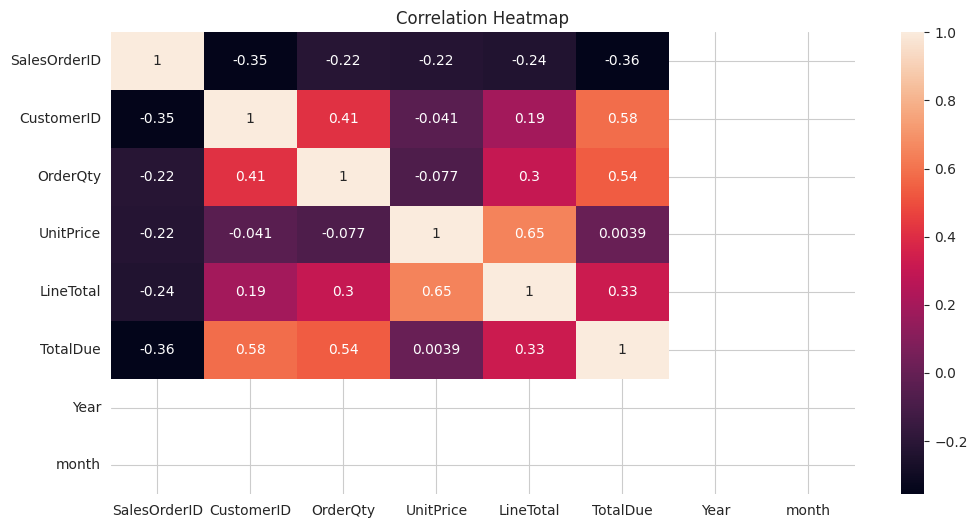

In [41]:
#Correlation Heatmap
num_df = df.select_dtypes(include=np.number)
sns.heatmap(
    num_df.corr(),
    annot=True
)
plt.title('Correlation Heatmap')

plt.show()

Observation :    
The heatmap showed that LineTotal and TotalDue had a strong relationship because when the sales amount of products increased the total order amount also increased. OrderQty and UnitPrice showed a moderate relationship with revenue-related columns indicating that both the quantity of products and their prices influence the final order value

In [42]:
# RMF Analysis
reference_date = df['OrderDate'].max() + pd.Timedelta(days=1)
rfm = df.groupby('CustomerID').agg({
    'OrderDate':lambda x: (reference_date - x.max()).days,
    'SalesOrderID': 'count',
    'TotalDue': 'sum'
})
rfm.columns = ['Recency', 'Frequency', 'Monetary']
rfm

,Recency,Frequency,Monetary
CustomerID,,,
11000,1,8,2.278408e+04
11001,1,11,2.237670e+04
11002,1,4,1.163908e+04
11003,1,9,2.470469e+04
11004,1,6,1.698273e+04
...,...,...,...
30114,1,30,5.272735e+04
30115,1,21,3.053199e+04
30116,1,119,6.319288e+06


Observation :     
Customers with recent purchases, frequent orders, and higher spending were identified as the most valuable customers

In [43]:
# Customer segmentation
rfm['Segment'] = np.where(
    rfm['Monetary'] > rfm['Monetary'].median(),
    'High Value',
    'Low Value'

)

In [44]:
rfm['Segment']

,Segment
CustomerID,
11000,High Value
11001,High Value
11002,High Value
11003,High Value
11004,High Value
...,...
30114,High Value
30115,High Value
30116,High Value


Observation :    
High-value customers represented a smaller customer group but contributed a major share of total revenue

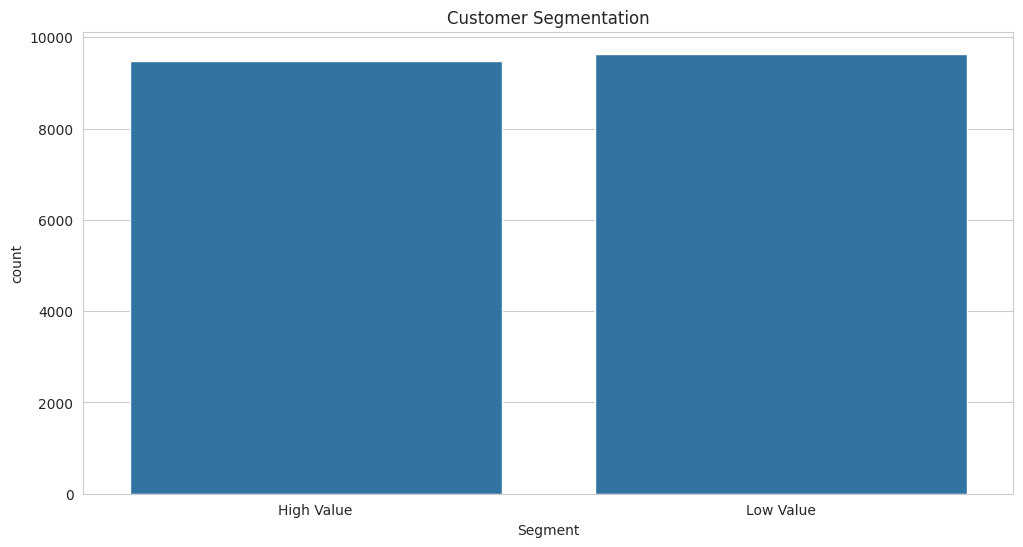

In [45]:
# Customer Segmentation Graph
sns.countplot(
    x='Segment',
    data=rfm
)

plt.title('Customer Segmentation')

plt.show()

Observation :     
The customer base is dominated by low-value customers while high-value customers have a stronger impact on revenue generation

In [46]:
# KPI Analysis
total_revenue = df['TotalDue'].sum()
total_orders = df['SalesOrderID'].nunique()
total_customers = df['CustomerID'].nunique()
average_order_value = df['TotalDue'].mean()

print('Total Revenue:', total_revenue)
print('Total Orders:', total_orders)
print('Total Customers:', total_customers)
print('Average Order Value:', average_order_value)

Total Revenue: 2926970124.0414
Total Orders: 31465
Total Customers: 19119
Average Order Value: 24126.627958500456


Observation :    
The KPI analysis provided an overview of the business performance. The company generated significant revenue from a large number of orders and customers. The Average Order Value showed the average amount spent per order helping to understand customer purchasing behavior and overall sales performance

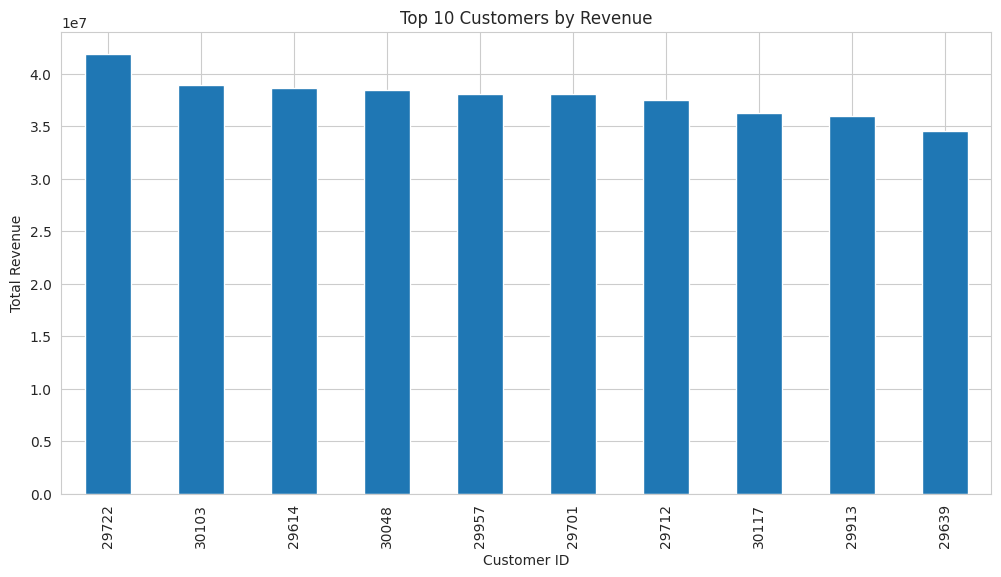

In [47]:
# Top 10 Customers by Revenue (Graph)
top_customers = (df.groupby('CustomerID')['TotalDue'].sum().nlargest(10))
top_customers.plot(kind='bar')
plt.title('Top 10 Customers by Revenue')
plt.xlabel('Customer ID')
plt.ylabel('Total Revenue')
plt.show()



Observation :     
Revenue was highly concentrated among a small number of customers emphasizing the importance of customer retention strategies